In [3]:
import pandas as pd
pd.set_option('future.no_silent_downcasting', True)
import numpy as np
from Bio import SeqIO, Seq, SeqRecord, Restriction, Phylo
import re

from matplotlib import pyplot as plt
from matplotlib import colormaps, colors, transforms, cm
from matplotlib.patches import Rectangle, FancyArrow, Arc
from matplotlib.lines import Line2D
import seaborn as sns
import colorcet
import colorsys

from scipy.cluster import hierarchy
from scipy import stats

import itertools
import string
import roman

from progressbar import ProgressBar

import pyranges1 as pr

import mathieu as mh
import importlib

import sys
sys.path.append('./')
import variables as v

In [4]:
importlib.reload(mh)
importlib.reload(v)

<module 'variables' from '/home/mathieu/Dropbox/Travail/postdoc_heasley/long_read_project/script/variables.py'>

In [5]:
wine_subclade = [f'YJM{i}' for i in [947, 948, 954, 955, 956, 957, 963, 964, 965, 967]]
fig_path = '/home/mathieu/postdoc_heasley/publications/subtelomere_paper/fig/'

In [6]:
collection = pd.read_excel('/home/mathieu/postdoc_heasley/collection/mccusker_collection_wild_annot.xlsx')
collection.index = collection['ID'].values

strain_order = collection.loc[wine_subclade].sort_values(by='Y\' element').index
strain_yprime_color = dict(zip(strain_order, [cm.viridis(i) for i in np.linspace(0,1,10)]))

# Individual subtelomeric reads

In [7]:
def read_type_transitions(df):

    df = df[(df['nuc']) | (df['subtelo'])]
    df = df[['nuc', 'subtelo']]
    tract_type_transitions = 0
    
    for i in range(df.shape[0]-1):
        j = i + 1
        
        test = df.iloc[[i,j]].values
        
        if (test[0] == test[1]).all():
            continue
        else:
            tract_type_transitions += 1
    
    if tract_type_transitions > 1:
        return False
    else:
        return True

In [8]:
def read_type_order(x):

    global anchor_aln
    global anchor_chrom_end
    
    anchor_strand, anchor_qstart, anchor_qend = anchor_aln.loc[['strand', 'qstart', 'qend']]
    
    subtelo_block = x.loc[x['subtelo']]
    subtelo_qstart = subtelo_block['qstart'].min()
    subtelo_qend = subtelo_block['qend'].max()

    if (anchor_chrom_end == 'left' and anchor_strand == 1) or (anchor_chrom_end == 'right' and anchor_strand == -1):
        #test = anchor_qstart > subtelo_qend
        test = subtelo_qend - anchor_qstart < 500
    
    elif (anchor_chrom_end == 'left' and anchor_strand == -1) or (anchor_chrom_end == 'right' and anchor_strand == 1):
        #test = anchor_qend < subtelo_qstart
        test = anchor_qend - subtelo_qstart < 500
    
    return test

In [9]:
def read_anchoring(df):
    # df must be a paf chunk sorted by query coordinates
    global paf
    
    anchor_flag = False

    anchor_aln_filter = (df['nuc']) & (df['aln_block_len']>8000)
    anchor_aln = df.loc[anchor_aln_filter]
        
    if anchor_aln.shape[0] == 0:
        return None
    
    elif anchor_aln.shape[0] > 0:
        # determine read orientation
        I = None
        if anchor_aln_filter[0]:
            I = list(df.index)
        elif anchor_aln_filter[-1]:
            I = list(df.index)
        
        anchor_aln = anchor_aln.sort_values(by='aln_block_len', ascending=False).iloc[0]

    paf.loc[anchor_aln.name, 'anchor'] = True

# TG repeat hit optimization with minimap

In [ ]:
K = [11,13,15,17,19]
M = [10,20,30,40,50]
N = [1,2,3,4]
S = [10,20,30,40,50]

tg_repeat_sizes = {}
bar_idx = 0
with ProgressBar(max_value=len(K)*len(M)*len(N)*len(S)) as bar:
    for (k,m,n,s) in itertools.product(K, M, N, S):
        paf = parse_paf(f'{base_dir}data/paf/YJM947_50X_k{k}_m{m}_n{n}_s{s}.aln.S288C_masked.repeats.subtypes.paf')
        paf = paf.loc[(paf['subject']=='TG_repeat') & (paf['mapq']>0)]
        tg_repeat_sizes[(k,m,n,s)] = paf['matches'].values
        bar_idx += 1
        bar.update(bar_idx)

In [ ]:
tg_repeat_hist = []
for k, sizes in tg_repeat_sizes.items():
    h, h_idx = np.histogram(sizes, bins=np.logspace(1, 3.5, 40))
    h = pd.Series(h, index=h_idx[:-1], name=k)
    tg_repeat_hist.append(h)
tg_repeat_hist = pd.DataFrame(tg_repeat_hist)

In [ ]:
asm_chrom_ends = pd.read_excel('assemblies_chrom_ends.xlsx')
asm_chrom_ends = asm_chrom_ends.loc[~asm_chrom_ends['start'].isna()].astype({'end':int, 'start':int, 'strand':int})

## Parse PAF alignments

In [10]:
anchor_chromosomes = [f'Chr{i}' for i in range(1,17)]

In [11]:
PAF = {}
READ_INFO = {}
GR = {}

for s in wine_subclade:
#for s in ['YJM955']:

    paf_subtelo_path = f'{v.base_dir}data/paf/{s}_50X.aln.S288C_masked.repeats.subtypes.paf'
    paf_subtelo = v.parse_paf(paf_subtelo_path)
    paf_subtelo = paf_subtelo.loc[paf_subtelo['subject'].isin(v.ty5_types + v.x_types + v.yprime_types)]
    paf_subtelo['source'] = 'subtelo'
    
    paf_tg_path = f'{v.base_dir}data/paf/{s}_50X.aln.S288C_masked.repeats.subtypes_TG.paf'
    paf_tg = v.parse_paf(paf_tg_path)
    paf_tg = paf_tg.loc[paf_tg['subject']=='TG_repeat']
    paf_tg['source'] = 'TG'
    
    paf_anchor_path = f'{v.base_dir}data/paf/{s}_50X.aln.canu_defaults_chromEnds.paf'
    paf_anchor = v.parse_paf(paf_anchor_path)
    paf_anchor['source'] = 'anchor'
    
    paf = pd.concat([paf_subtelo, paf_tg, paf_anchor]).reset_index(drop=True)
    # eliminate non-primary alignments and sort by query coordinates
    paf = paf.loc[paf[16]=='tp:A:P'].sort_values(by=['qend','qstart'])

    # determine if read is terminal
    paf['left_terminal'] = paf['qstart']<10
    paf['right_terminal'] = (paf['qlen']-paf['qend'])<10
    paf['terminal'] = (paf['left_terminal'] | paf['right_terminal'])
    # convert strand
    paf['strand'] = np.where(paf['strand']=='+', 1, -1)
    # add strain tag
    paf['strain'] = s
    # add filters for subject types
    paf['nuc'] = paf['subject'].isin(anchor_chromosomes)
    paf['yprime'] = paf['subject'].isin(v.yprime_types)
    paf['subtelo'] = paf['subject'].isin(v.at_subtelomeres)
    paf['subtelo_woTY5'] = paf['subject'].isin(v.at_subtelomeres_woTY5)
    paf['TG_repeat'] = paf['subject'] == 'TG_repeat'
    paf['type'] = 'repeat'
    # boolean column for anchor alignment
    paf['anchor'] = False
    paf['telo'] = False
    
    R = paf['rid'].unique()
    read_info = {rid:{'anchor_flag':False,
                     'yprime_flag':False,
                     'telo_flag':False,
                     'strand_flag':False,
                     'type_transition_flag':False,
                     'type_order_flag':False} for rid in R}
   
    for rid, sub_paf in paf.groupby('rid'):        
        
        if not sub_paf['subtelo'].any():
            continue

        # Anchoring
        # Ctireria: 1) subject must be a nuclear chromosome 2) alignment block length must be 20 kb or more
        anchor_aln = sub_paf.loc[(sub_paf['nuc']) & (sub_paf['aln_block_len']>20000)]
    
        if anchor_aln.shape[0] == 0:
            continue
        
        else:
            anchor_aln = anchor_aln.sort_values(by='aln_block_len', ascending=False).iloc[0]
    
        paf.loc[anchor_aln.name, 'anchor'] = True
        read_info[rid]['anchor_flag'] = True
        
        anchor_chrom, anchor_chrom_len, anchor_strand, anchor_sstart = anchor_aln.loc[['subject', 'slen', 'strand', 'sstart']]
        anchor_chrom_end = None
        
        if anchor_aln.loc['send'] > 0.75 * anchor_chrom_len:
            anchor_chrom_end = 'right'
        elif anchor_aln['sstart'] < 0.25 * anchor_chrom_len:
            anchor_chrom_end = 'left'
        else:
            continue
    
        # if read is yprime informative, check that all annotations are on the same strand.
        at_subtelo_strand = sub_paf.loc[sub_paf['subtelo_woTY5'], 'strand'].unique()
        
        if at_subtelo_strand.shape[0] == 1:
            at_subtelo_strand = at_subtelo_strand[0]
            # Check that anchor strand and annot strand are consistent, depending on chromosome end
            if anchor_chrom_end == 'left' and at_subtelo_strand == anchor_strand*-1:
                read_info[rid]['strand_flag'] = True
            elif anchor_chrom_end == 'right' and at_subtelo_strand == anchor_strand:
                read_info[rid]['strand_flag'] = True
        else:
            continue
                
        # filter for number of subject type transitions
        if read_info[rid]['strand_flag']:

            if read_type_transitions(sub_paf):
                read_info[rid]['type_transition_flag'] = True
    
                # filter for relative orientation of subtelo annots to anchor
                if read_type_order(sub_paf):
                    read_info[rid]['type_order_flag'] = True
    
        # boolean flag if y prime informative
        read_info[rid]['yprime_flag'] = sub_paf['yprime'].any()
        # boolean flag if telo
        telo_bool = sub_paf.iloc[[0, -1]]['TG_repeat']
        telo_flag = telo_bool.sum() == 1
        read_info[rid]['telo_flag'] = telo_flag
        if telo_flag:
            telo_aln = telo_bool.loc[telo_bool==True].index
            paf.loc[telo_aln, 'telo'] = True
        
        # non-boolean read_info fields
        read_info[rid]['strain'] = s
        read_info[rid]['chrom'] = anchor_chrom
        read_info[rid]['chrom_end'] = anchor_chrom_end
        read_info[rid]['anchor_strand'] = anchor_strand
        read_info[rid]['anchor_chrom_len'] = anchor_chrom_len
        
        at_subtelo_len = sub_paf.groupby('subject')['aln_block_len'].sum()
        for at, at_len in at_subtelo_len.items():
            if at in v.at_subtelomeres:
                read_info[rid].update({f'len_{at}': at_len})
        
    read_info = pd.DataFrame(read_info).T
    paf = paf.set_index('rid')
    
    PAF[s] = paf
    READ_INFO[s] = read_info

    print(f'{s} {paf.shape[0]}')

YJM947 38242
YJM948 25010
YJM954 29962
YJM955 42245
YJM956 40382
YJM957 40654
YJM963 27408
YJM964 26654
YJM965 26328
YJM967 15826


# Y' vs interstitial vs cap length

In [ ]:
read_info = pd.concat(READ_INFO.values())
read_info = read_info.loc[(read_info['chrom_end'].isin(['left', 'right'])) &
                          ((read_info['yprime_flag']) | (read_info['telo_flag'])) & 
                          (read_info['type_order_flag']) &
                          (read_info['type_transition_flag']) &
                          (read_info['strand_flag'])]
R = read_info.index

ST_LEN_INDIV = pd.concat(PAF.values()).loc[R].reset_index().rename({'index':'rid'}, axis=1)

In [ ]:
len_yprime = paf.loc[paf['yprime']].groupby('rid')['aln_block_len'].sum().rename('len_yprime')
len_TG = paf.loc[(paf['TG_repeat']) & (~paf['telo'])].groupby('rid')['aln_block_len'].sum().rename('len_TG')
len_telo = paf.loc[paf['telo']].groupby('rid')['aln_block_len'].sum().rename('len_telo')

ST_LEN = pd.concat([len_yprime, len_TG, len_telo], axis=1)
ST_LEN['len_yprime'] = ST_LEN['len_yprime'].fillna(0)
ST_LEN['len_TG'] = ST_LEN['len_TG'].fillna(0)
ST_LEN = ST_LEN.merge(read_info[['strain', 'chrom', 'chrom_end']], left_index=True, right_index=True)

## Fig S4A-B

In [ ]:
fig, axes = plt.subplots(ncols=2, figsize=[12,5])

ax = axes[0]

sns.violinplot(x='strain', y='len_telo', order=strain_order, cut=0,
               density_norm='width', width=0.93,
               hue='strain', palette=strain_yprime_color, saturation=1,
               data=ST_LEN, ax=ax)

ax.tick_params(axis='x', rotation=90)
ax.set_xlabel('')
ax.set_ylim(0, 1200)
ax.set_ylabel('TG cap length (bp)')

sns.despine(ax=ax)
ax.text(-0.07, 1.07, 'A', size=24, fontweight='bold', transform=ax.transAxes)

ax = axes[1]

dat = ST_LEN.copy()

dat['chrom'] = dat['chrom'].apply(lambda x: int(x[3:]))
dat['chrom_end'] = dat['chrom_end'].map({'left':'L', 'right':'R'})
dat['CE'] = dat.apply(lambda x: f'{roman.toRoman(x["chrom"])}-{x["chrom_end"]}', axis=1)
CE_order = [f'{roman.toRoman(c)}-{e}' for c in range(1,17) for e in ('L','R')]

dat = dat.groupby(['strain', 'CE'])['len_telo'].median().rename('median_len_telo')\
    .reset_index().pivot_table(index='CE', columns='strain', values='median_len_telo')
# remove cells for which no telo call were made on any haplotype
dat.loc['IV-L', 'YJM956'] = np.nan
dat.loc['IX-R', 'YJM947'] = np.nan
dat.loc['VIII-L', 'YJM965'] = np.nan

sns.heatmap(dat.loc[CE_order, strain_order], cmap='plasma', 
            cbar_kws={'label':'median TG cap length (bp)'}, ax=ax)
ax.set_yticks(np.arange(dat.shape[0])+0.5)
ax.set_yticklabels(CE_order)
ax.set_ylabel('')

ax.text(-0.17, 1.07, 'B', size=24, fontweight='bold', transform=ax.transAxes)

plt.tight_layout()
for ext in ['png', 'svg']:
    plt.savefig(f'{fig_path}FigS4AB.{ext}', dpi=300)
    
plt.show()
plt.close()

# Neighbors analysis

In [ ]:
def paf_to_pr(paf):
    pr_from_df = pr.PyRanges(paf.reset_index()[['rid', 'qstart', 'qend', 'strand', 'subject', 'strain']]\
    .rename({'rid':'Chromosome', 'qstart':'Start', 'qend':'End', 'strand':'Strand'}, axis=1)\
                            .replace({'Strand':{1:'+',-1:'-'}}))
    return pr_from_df

In [ ]:
# Filter the reads with same parameters as plots
read_info = pd.concat(READ_INFO.values())
read_info = read_info.loc[(read_info['chrom_end'].isin(['left', 'right'])) &
                          ((read_info['yprime_flag']) | (read_info['telo_flag'])) & 
                          (read_info['type_order_flag']) &
                          (read_info['type_transition_flag']) &
                          (read_info['strand_flag'])]
read_all_keep = list(read_info.index)

In [ ]:
paf = pd.concat(PAF.values()).loc[read_all_keep].reset_index()
paf_yprime = paf.loc[paf['yprime']]
paf_TG = paf.loc[(paf['TG_repeat']) | (paf['yprime'])]

pr_yprime = paf_to_pr(paf_yprime)
pr_TG = paf_to_pr(paf_TG)

## Y prime types with each other

In [ ]:
yprime_types_counts_paf = paf_yprime.value_counts('subject')
yprime_types_major = yprime_types_counts_paf.iloc[:6].index

In [ ]:
Y_PRIME_NEIGHBORS = []

upstream = pr_yprime.nearest_ranges(pr_yprime, exclude_overlaps=True, strand_behavior='same', direction='upstream')
upstream['direction'] = -1
downstream = pr_yprime.nearest_ranges(pr_yprime, exclude_overlaps=True, strand_behavior='same', direction='downstream')
downstream['direction'] = 1

Y_PRIME_NEIGHBORS.append(upstream)
Y_PRIME_NEIGHBORS.append(downstream)

Y_PRIME_NEIGHBORS = pd.concat(Y_PRIME_NEIGHBORS).reset_index(drop=True)
Y_PRIME_NEIGHBORS['Direction'] = np.where(Y_PRIME_NEIGHBORS['Strand']=='+', Y_PRIME_NEIGHBORS['direction'], Y_PRIME_NEIGHBORS['direction']*-1)

## TG repeats

In [ ]:
TG_NEIGHBORS = []

upstream = pr_yprime.nearest_ranges(pr_TG, exclude_overlaps=True, strand_behavior='same', direction='upstream')
upstream['direction'] = -1
downstream = pr_yprime.nearest_ranges(pr_TG, exclude_overlaps=True, strand_behavior='same', direction='downstream')
downstream['direction'] = 1

TG_NEIGHBORS.append(upstream)
TG_NEIGHBORS.append(downstream)

TG_NEIGHBORS = pd.concat(TG_NEIGHBORS).reset_index(drop=True)
TG_NEIGHBORS['Direction'] = np.where(TG_NEIGHBORS['Strand']=='+', TG_NEIGHBORS['direction'], TG_NEIGHBORS['direction']*-1)
TG_NEIGHBORS['TG'] = TG_NEIGHBORS['subject_b'] == 'TG_repeat'
TG_NEIGHBORS['len'] = (TG_NEIGHBORS['End']-TG_NEIGHBORS['Start']).abs()
TG_NEIGHBORS['len_b'] = (TG_NEIGHBORS['End_b']-TG_NEIGHBORS['Start_b']).abs()

## Fig S4C-D

In [ ]:
fig, axes = plt.subplots(ncols=2, figsize=[12,5])

ax = axes[0]

dat = ST_LEN_INDIV.loc[(ST_LEN_INDIV['TG_repeat']) & (~ST_LEN_INDIV['telo'])]
sns.violinplot(x='strain', y='aln_block_len', order=strain_order, cut=0,
               density_norm='width', width=0.93,
              hue='strain', palette=strain_yprime_color, saturation=1,
              data=dat, ax=ax)
ax.tick_params(axis='x', rotation=90)
ax.set_xlabel('')
ax.set_ylim(0, 900)
ax.set_ylabel('interstitial TG length (bp)')
sns.despine(ax=ax)

ax.text(-0.07, 1.07, 'C', size=24, fontweight='bold', transform=ax.transAxes)

ax = axes[1]

dat = TG_NEIGHBORS.loc[TG_NEIGHBORS['TG']==True].copy()
dat['Direction'] = dat['Direction'].map({1:'downstream', -1:'upstream'})
dat = dat.pivot_table(index=['subject', 'Direction'], columns='strain', values='len_b', 
                      aggfunc='median')

sns.heatmap(dat.loc[y_prime_order, strain_order], 
           cmap='plasma', cbar_kws={'label':'median TG length (bp)'},
            ax=ax)
y_labels = []
for yt in ax.get_yticklabels():
    y, d = yt.get_text().split('-')
    y = y.split('.')[1]
    y_labels.append(f'type {y} {d}')
ax.set_yticklabels(y_labels)
ax.set_ylabel('')
ax.set_xlabel('')

ax.text(-0.17, 1.07, 'D', size=24, fontweight='bold', transform=ax.transAxes)
   
plt.tight_layout()

for ext in ['png', 'svg']:
    plt.savefig(f'{fig_path}FigS4CD.{ext}', dpi=300)
#plt.show()
plt.close()

In [ ]:
fig = plt.figure(figsize=[10,4])
gs = plt.GridSpec(ncols=2, nrows=1, wspace=0.5)

direction_alias = {-1:'upstream', 1:'downstream'}
direction_ax = {-1:0, 1:1}

for d, df in Y_PRIME_NEIGHBORS.groupby('Direction'):
    ax = fig.add_subplot(gs[direction_ax[d]])
    
    dat = df.value_counts(['subject', 'subject_b']).reset_index()
    dat['proportion'] = dat['count']/yprime_types_counts_paf.loc[dat['subject']].values
    
    dat = dat.pivot_table(index='subject', columns='subject_b', values='proportion')\
        .loc[yprime_types_major, yprime_types_major]
    hm = ax.imshow(dat.fillna(0), cmap='viridis', vmin=0, vmax=0.5)
    
    ax.set_title(direction_alias[d])
    X = np.arange(len(yprime_types_major))
    ax.set_yticks(X, labels=[v.at_alias[yt] for yt in yprime_types_major])
    ax.set_xticks(X)
    ax.set_xticklabels([v.at_alias[yt] for yt in yprime_types_major], rotation=45, ha='right')

    if d == 1:
        x, y, w, h = ax.get_position().bounds
        ax_cbar = fig.add_axes([x*1.08, (y+h)*1.08, w*0.25, h*0.05])
        cb = plt.colorbar(hm, cax=ax_cbar, orientation='horizontal')
        cb.outline.set_visible(False)
        cb_x_ticks = np.linspace(0, 0.5, 6)
        ax_cbar.set_xticks(cb_x_ticks)
        ax_cbar.set_xticklabels([f'{x*100:.0f}' for x in cb_x_ticks])
        ax_cbar.text(1.05, 0.5, '% copies', 
                     ha='left', va='center', transform=ax_cbar.transAxes)

In [ ]:
for s, paf in PAF.items():
    dat = paf.loc[paf['anchor'], 'aln_block_len'].sort_values()
    plt.plot(dat, np.linspace(0, 1, dat.shape[0]), label=s)
plt.legend()

# Export subtelomeric read sequences

In [ ]:
SEQ_STORE = {}

for s in ['YJM947']:

    SEQ_STORE[s] = {}
    
    paf = PAF[s]
    paf_anchor = paf.loc[paf['anchor']==True]
    read_info = READ_INFO[s]
    reads = {seq.id:seq for seq in SeqIO.parse(f'{base_dir}data/reads/{s}_50X.fasta', 'fasta')}
    
    
    f = (read_info['chrom_end'].isin(['left', 'right'])) & \
    ((read_info['yprime_flag']) | (read_info['telo_flag'])) & \
    (read_info['type_order_flag']) & \
    (read_info['type_transition_flag']) & \
    (read_info['strand_flag'])
    
    for (chrom, chrom_end), ri in read_info.loc[f].groupby(['chrom', 'chrom_end']):

        seq_store = []
        for rid in ri.index:
        
            strand, qlen, qstart, qend, slen, sstart, send = paf_anchor.loc[rid, ['strand', 'qlen', 'qstart', 'qend', 'slen', 'sstart', 'send']].values
           
            if (chrom_end, strand) in [('left', -1), ('right', 1)]: 
                new_seq = reads[rid].seq[qend-1:]
                new_sr = SeqRecord.SeqRecord(new_seq, id=f'{rid}_{chrom}_{chrom_end}', description='')
                seq_store.append(new_sr)

            elif (chrom_end, strand) in [('left', 1), ('right', -1)]:
                new_seq = reads[rid].seq[:qstart].reverse_complement()
                new_sr = SeqRecord.SeqRecord(new_seq, id=f'{rid}_{chrom}_{chrom_end}_RC', description='')
                seq_store.append(new_sr)
        
        SEQ_STORE[s][(chrom, chrom_end)] = seq_store

In [ ]:
for s in ['YJM947']:
    for chrom, chrom_end in itertools.product([f'ref|NC_0011{i}|' for i in range(33, 49)], ['left', 'right']):
        if (chrom, chrom_end) in SEQ_STORE[s]:
            with open(f'{base_dir}subtelomeres/anchor_reads/{s}_{nuc_chr_alias[chrom]}_{chrom_end}.fasta', 'w') as handle:
                SeqIO.write(SEQ_STORE[s][(chrom, chrom_end)], handle, 'fasta')

In [ ]:
read_sort_columns = [f'len_{i}' for i in v.yprime_types] + ['sstart']
rainbow = colormaps['gist_rainbow']

for s in wine_subclade:
#for s in ['YJM955']:
    
    paf = PAF[s]
    read_info = READ_INFO[s]
    read_info = read_info.loc[(read_info['chrom_end'].isin(['left', 'right'])) &
                              ((read_info['yprime_flag']) | (read_info['telo_flag'])) & 
                              (read_info['type_order_flag']) &
                              (read_info['type_transition_flag']) &
                              (read_info['strand_flag'])
    ]
    
    fig = plt.figure(figsize=[15,22])
    gs = plt.GridSpec(nrows=16, ncols=2, hspace=0.3, wspace=0.2,
                      left=0.03, right=0.97, top=0.97, bottom=0.02)
    
    fig.text(0.5, 0.99, s, va='top', ha='center', size=24)
    
    ax_chrom = dict(zip(anchor_chromosomes, range(16)))
    ax_chrom_end = {'left':0, 'right':1}
    
    for (chrom, chrom_end, anchor_chrom_len), ri in read_info.groupby(['chrom', 'chrom_end', 'anchor_chrom_len']):
    
        ax = fig.add_subplot(gs[ax_chrom[chrom], ax_chrom_end[chrom_end]])
    
        n_reads = ri.shape[0]
        R = dict(zip(ri.sort_values(by=[i for i in read_sort_columns if i in ri.columns]).index, range(n_reads)))
    
        annot_patches = []

        for rid in ri.index:
        
            telo_flag = ri.loc[rid, 'telo_flag']
            sub_paf = paf.loc[rid].copy().reset_index(drop=True)
            
            anchor_aln = sub_paf.set_index('anchor').loc[True]
            strand, qlen, qstart, qend, slen, sstart, send = anchor_aln.loc[['strand', 'qlen', 'qstart', 'qend', 'slen', 'sstart', 'send']].values
        
            y = R[rid]
            dx = (y%2)*3000
            ref_point = np.nan
            read_offset = np.nan
            
            if chrom_end == 'left':
                ref_point = sstart
        
                if strand == -1:
                    read_offset = qend
                    
                elif strand == 1:
                    read_offset = qstart
        
            elif chrom_end == 'right':
                ref_point = send
        
                if strand == -1:
                    read_offset = qstart
                elif strand == 1:
                    read_offset = qend
                    
            sub_paf['qstart'] = ref_point + strand * (sub_paf['qstart'] - read_offset)
            sub_paf['qend'] = ref_point + strand * (sub_paf['qend'] - read_offset)
            sub_paf['strand'] = sub_paf['strand'] * -1
        
            if telo_flag:
                read_color = '0.8'
            else:
                read_color = 'lightcoral'
        
            read_span = [ref_point + strand * (x - read_offset) for x in (0, qlen)]
            ax.plot(read_span, [y, y], color='w', lw=0, zorder=1)
            fa = FancyArrow(read_span[0], y, (read_span[1]-read_span[0]), 0, width=0.25, fc=read_color, lw=0, alpha=1, zorder=1,
                                head_width=0.3, head_length=0)
            ax.add_patch(fa)
            
            for i in sub_paf.index:
                qstart, qend, strand, subject, sstart, send, nuc, subtelo = sub_paf.loc[i, ['qstart','qend','strand','subject','sstart','send','nuc','subtelo']]
                X = [qstart, qend][::strand*(-1)]
                arrow_length = np.abs(qend-qstart)
    
    
                if subject == 'TG_repeat':
                    fa = FancyArrow(X[0], y, (X[1]-X[0]), 0, width=0.8, fc=v.at_color[subject], lw=0, zorder=2,
                                    length_includes_head=False, head_width=0.8, head_length=0)
                    annot_patches.append(fa)
                
                elif subtelo:
                    fa = FancyArrow(X[0], y, (X[1]-X[0]), 0, width=0.8, fc=v.at_color[subject], lw=0, zorder=2,
                                    length_includes_head=True, head_width=0.8, head_length=np.min([0.3*v.repeats_lengths[subject], arrow_length]))
                    annot_patches.append(fa)
                    
                elif nuc:
                    fa = FancyArrow(X[0], y, (X[1]-X[0]), 0, width=0.6, fc='grey', lw=0, zorder=0, alpha=0.6,
                                    length_includes_head=True, head_width=0.8, head_length=np.min([1000, arrow_length]))
                    
                else:
                    fa = FancyArrow(X[0], y, (X[1]-X[0]), 0, width=0.6, fc='gold', lw=0, zorder=2,
                                    length_includes_head=True, head_width=0.8, head_length=np.min([100, arrow_length]))
                
                ax.add_patch(fa)

                plot_rainbow = False
                if plot_rainbow:
                    if subject in v.yprime_types:
    
                        ax.text(np.mean(X), y, subject.split('.')[1], ha='center', va='center', size=2, zorder=4)
                        X1 = np.linspace(X[0], X[1], 20)
                        C = np.array([sstart, send])/6428
                        C = np.linspace(C[0], C[1], 19)
                        for i in range(19):
                            fa = FancyArrow(X1[i], y, (X1[i+1]-X1[i]), 0, width=0.08, fc=rainbow(C[i]), lw=0, alpha=1, zorder=3,
                                    head_width=0.2, head_length=0)
                            ax.add_patch(fa)
                
            #if chrom_end == 'left':
            #    ax.text(8000+dx, y, rid.split('-')[0], size=3, va='center', ha='left')
            #elif chrom_end == 'right':
            #    ax.text(anchor_chrom_len-(8000+dx), y, rid.split('-')[0], size=3, va='center', ha='right')
        
        ax.set_yticks([])
        ax.set_yticklabels([])
        
        if n_reads < 5:
            ax.set_ylim(ax.get_ylim()[0], 7)
            
        if len(annot_patches) > 0:
                  
            patches_xcoords = np.concatenate([p.get_xy()[:,0] for p in annot_patches])
            
            if chrom_end == 'left':
                ax.axvline(0, zorder=0, ls='--', lw=0.5, c='k')
                #right_limit = patches_xcoords.max()+1e4
                right_limit = 3e4
                ax.set_xlim(ax.get_xlim()[0], right_limit)
                ax.text(1.02, 0.5, f'{roman.toRoman(int(chrom[3:]))}-L', size=10, ha='left', va='center', transform=ax.transAxes)
            elif chrom_end == 'right':
                ax.axvline(anchor_chrom_len, zorder=0, ls='--', lw=0.5, c='k')
                #left_limit = patches_xcoords.min()-1e4
                left_limit = anchor_chrom_len-3e4
                ax.set_xlim(left_limit, ax.get_xlim()[1])
                ax.text(-0.02, 0.5, f'{roman.toRoman(int(chrom[3:]))}-R', size=10, ha='right', va='center', transform=ax.transAxes)
                
            xticks = np.round(np.array(ax.get_xlim())*1e-3)
            xticks = np.round(np.linspace(xticks[0], xticks[1], 4))
            ax.set_xticks(xticks*1e3)
            ax.set_xticklabels([f'{x:.0f}' for x in xticks], size=7)
    
            for sp in ['top', 'left', 'right']:
                ax.spines[sp].set_visible(False)
    
        else:
            ax.axis('off')

    print(s)
    
    #plt.savefig(f'{v.fig_path}subtelomere_structure/new_{s}.png', dpi=800)
    #plt.show()
    plt.close()

# Y' encoding

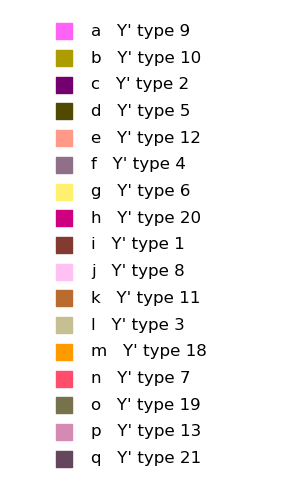

In [32]:
fig, ax = plt.subplots(figsize=[3,5])
for y, yt in enumerate(v.yprime_types):
    ax.scatter([0.1], [y], marker='s', s=120, c=v.at_color[yt])
    ax.text(0.15, y, f'{v.yprime_types_encoding[yt]}   {v.at_alias[yt]}', size=12, ha='left', va='center')

ax.set_xlim(0,0.5)
ax.invert_yaxis()
ax.axis('off')

plt.tight_layout()
#plt.savefig(f'yprime_encoding.png', dpi=300)
plt.show()
plt.close()

In [ ]:
export = []
for (s, ce, chrom, h) in itertools.product(wine_subclade,
                                           ['L', 'R'],
                                           range(1,17),
                                           [0,1]):
    export.append([s, chrom, ce, h])
pd.DataFrame(export, columns=['strain', 'chrom', 'chrom_end', 'haplotype']).to_csv(f'{v.base_dir}tables/subtelomere_structure.csv')

# Parse and plot visually called structures

In [34]:
structure = pd.read_excel(f'{v.base_dir}tables/subtelomere_structure.xlsx')
structure['len_array'] = structure['structure'].apply(lambda x: len(x))
structure['Structure'] = structure['structure'].apply(lambda x: list(x))
max_len_array = structure.groupby('strain')['len_array'].max().sort_values()

y_prime_types_rev_encoding = {j:i for i,j in v.yprime_types_encoding.items()}
y_prime_types_rev_encoding['X'] = 'X_coreDCBA'
y_prime_types_rev_encoding['T'] = 'TG_repeat'
y_prime_types_rev_encoding['5'] = 'TY5-I#LTR/Copia'

## Fig 2

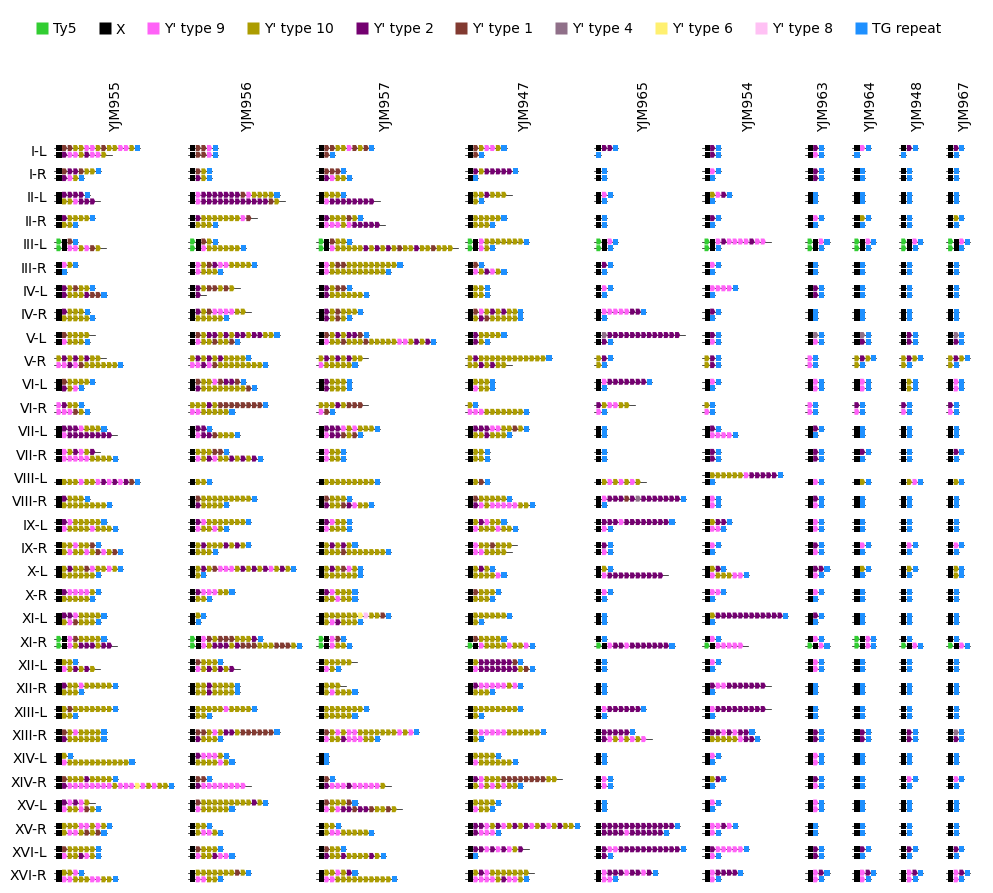

In [35]:
S = v.strains_info.loc[wine_subclade, 'Y\' element'].sort_values(ascending=False).index
ax_strain = dict(zip(S, range(10)))
ce_axis = dict(zip([f'{chrom}{ce}' for chrom in range(1,17) for ce in ['L','R']], range(32)))
gap = 0.1

fig = plt.figure(figsize=[10,9])
gs = plt.GridSpec(ncols=10, nrows=32, hspace=0.75, wspace=0.1,
                 width_ratios=max_len_array.loc[S]+3.5,
                  left=0.05, right=0.98, bottom=0.03, top=0.85)

for (s, chrom, ce), df in structure.sort_values(by='structure').groupby(['strain', 'chrom', 'chrom_end']):
    
    chrom_ce = f'{chrom}{ce}'
    chrom_ce_display = f'{roman.toRoman(int(chrom))}-{ce}'
    ax_idx_ce = ce_axis[chrom_ce]
    ax_idx_s = ax_strain[s]
    
    ax = fig.add_subplot(gs[ax_idx_ce, ax_idx_s])

    y = 0
    
    for u in df['Structure'].values:
        x = 0
    
        for k in u:
            at = y_prime_types_rev_encoding[k]
            fc = v.at_color[at]

            if k in ['X','T']:
                l = 1
                hl = 0
            else:
                l = 1
                hl = 0.3
                
            X = [x, x + l - gap]
            
            fa = FancyArrow(X[0], y, l, 0, width=0.9, fc=fc, lw=0, zorder=1,
                    length_includes_head=True, head_width=0.9, head_length=hl,
                           clip_on=False)
            ax.add_patch(fa)
    
            x += (l + gap)

        X = [-0.5, x-gap]
        if u[-1] != 'T':
            X[1] += 1
        ax.plot(X, [y,y], lw=0.5, c='k', zorder=0, clip_on=False)
        y += 1

    ax.set_xlim(-0.5, max_len_array[s]+3)
    ax.set_xticks([0, max_len_array[s]+1])
    
    ax.set_ylim(-0.5, 1.5)
    ax.axis('off')
    
    if ax_idx_s == 0:
        ax.text(-0.05, 0.5, chrom_ce_display, size=10, ha='right', va='center', transform=ax.transAxes)
    if ax_idx_ce == 0:
        ax.text(0.5, 2, s, size=10, ha='center', va='bottom', rotation=90, transform=ax.transAxes)


legend_elms = [Line2D([0], [0], marker='s', ms=8, lw=0, mec=(1,1,1,0),
                      mfc=v.at_color[y_prime_types_rev_encoding[k]],
                     label=v.at_alias[y_prime_types_rev_encoding[k]]) for k in ('5', 'X', 'a', 'b', 'c', 'i', 'f', 'g', 'j', 'T')]
ax = fig.add_axes([0.05, 0.9, 0.9, 0.1])
ax.axis('off')
ax.legend(handles=legend_elms, ncols=10, handlelength=0, frameon=False)

#for ext in ['png', 'svg', 'pdf']:
#    plt.savefig(f'{fig_path}Fig2.{ext}', dpi=300)

plt.show()
plt.close()